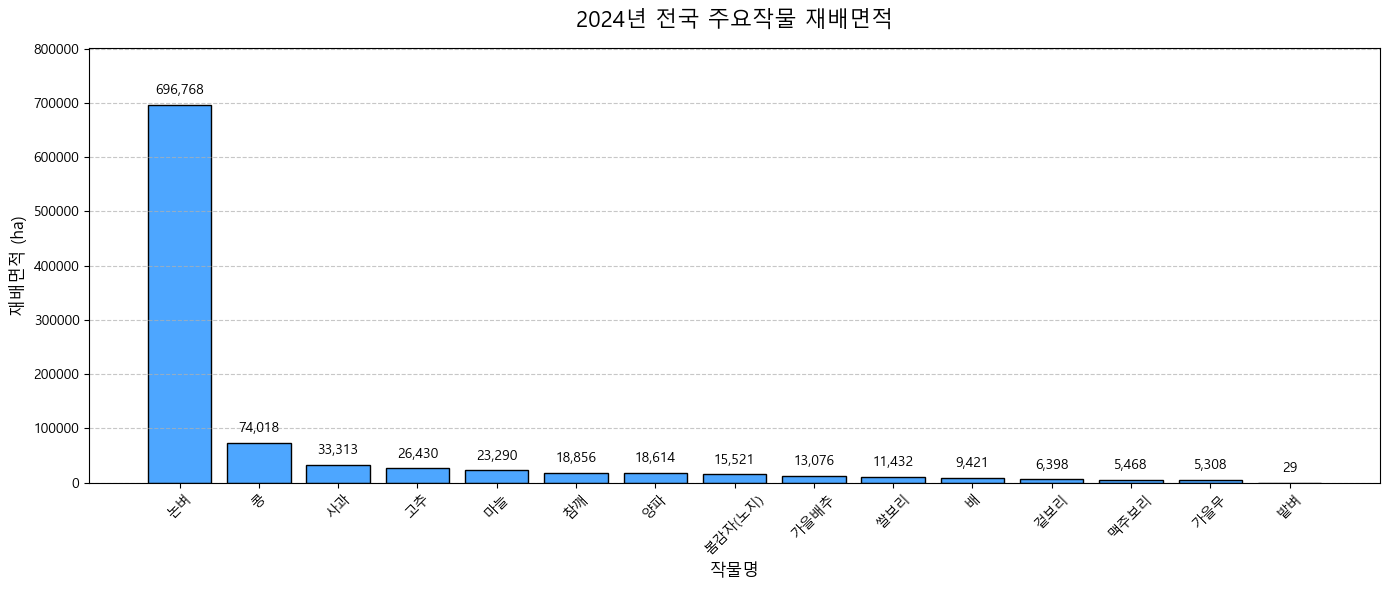

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# 1. 한글 폰트 설정 (그래프에서 한글이 깨지는 것을 방지)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')   # 맥 애플고딕
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 불러오기 (한국어 환경의 CSV이므로 인코딩을 cp949로 지정)
file_path = '주요작물_표본오차_및_신뢰구간_전국__20260505083317.csv'
df = pd.read_csv(file_path, encoding='cp949')

# 3. 데이터 전처리
# 첫 번째 행('작물별', '재배면적(ha)')은 분석용 수치 데이터가 아니므로 제외
df_clean = df.iloc[1:].copy()

# '2024' 열의 데이터를 숫자(float) 형태로 변환
df_clean['2024'] = df_clean['2024'].astype(str).str.replace(',', '')
df_clean['2024'] = pd.to_numeric(df_clean['2024'], errors='coerce')

# ★ 추가: 재배면적이 큰 순서대로 내림차순 정렬 ★
df_clean = df_clean.sort_values(by='2024', ascending=False)

# 4. 막대그래프 시각화
plt.figure(figsize=(14, 6)) # 그래프 크기 설정

# ★ 수정: 막대그래프를 생성하고 반환되는 객체를 bars 변수에 저장 ★
bars = plt.bar(df_clean['작물별'], df_clean['2024'], color='#4da6ff', edgecolor='black')

# 그래프 제목 및 라벨 설정
plt.title('2024년 전국 주요작물 재배면적', fontsize=16, pad=15)
plt.xlabel('작물명', fontsize=12)
plt.ylabel('재배면적 (ha)', fontsize=12)

# X축 작물명 글씨가 겹치지 않도록 45도 회전
plt.xticks(rotation=45) 

# ★ 추가: 막대 위에 데이터 레이블 표시 ★
for bar in bars:
    yval = bar.get_height()
    # 텍스트 위치: X축 중앙, Y축 높이 약간 위 / 천 단위 콤마 적용
    plt.text(bar.get_x() + bar.get_width()/2, yval + (df_clean['2024'].max() * 0.02), 
             f'{yval:,.0f}', ha='center', va='bottom', fontsize=10)

# ★ 추가: 데이터 레이블이 천장에 닿아 잘리지 않도록 Y축 범위를 15% 여유 있게 설정 ★
plt.ylim(0, df_clean['2024'].max() * 1.15)

# Y축에 보조선 추가하여 데이터 수치 파악을 용이하게 함
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()

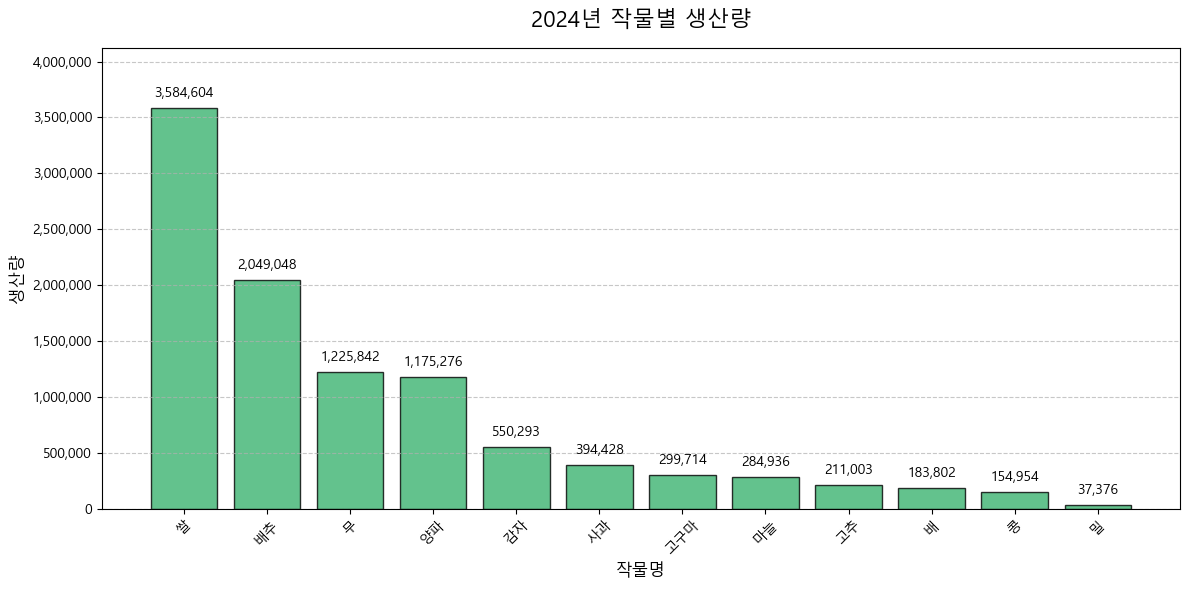

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import platform
import matplotlib.ticker as ticker

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')   # 맥 애플고딕
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = '작물별생산량2024.csv'
try:
    # 한글 데이터가 포함된 경우를 대비해 인코딩 처리
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8')

# 3. 데이터 전처리
# 생산량 데이터를 숫자형으로 확실하게 변환
df['생산량'] = pd.to_numeric(df['생산량'], errors='coerce')

# 그래프를 보기 좋게 만들기 위해 생산량을 기준으로 내림차순 정렬
df_sorted = df.sort_values(by='생산량', ascending=False)

# 4. 막대그래프 시각화
plt.figure(figsize=(12, 6))

# 막대그래프 생성 (X축: 작물별, Y축: 생산량)
bars = plt.bar(df_sorted['작물별'], df_sorted['생산량'], color='mediumseagreen', edgecolor='black', alpha=0.8)

# 타이틀 및 라벨 설정
plt.title('2024년 작물별 생산량', fontsize=16, pad=15)
plt.xlabel('작물명', fontsize=12)
plt.ylabel('생산량', fontsize=12)

# X축 작물명이 겹치지 않도록 45도 회전
plt.xticks(rotation=45)

# Y축 수치에 천 단위 콤마(,) 추가하여 가독성 향상
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# ★ 추가: 막대 위에 데이터 레이블 표시 ★
for bar in bars:
    yval = bar.get_height()
    # 텍스트 위치: X축 중앙, Y축 높이 약간 위 / 천 단위 콤마 적용
    plt.text(bar.get_x() + bar.get_width()/2, yval + (df_sorted['생산량'].max() * 0.02), 
             f'{yval:,.0f}', ha='center', va='bottom', fontsize=10)

# ★ 추가: 데이터 레이블이 천장에 닿아 잘리지 않도록 Y축 범위를 15% 여유 있게 설정 ★
plt.ylim(0, df_sorted['생산량'].max() * 1.15)

# Y축 보조선 추가
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()

In [3]:
import requests
import pandas as pd
import math
import time

# 1. API 기본 설정
API_KEY = "2026b9e29907824f78354ccc9f9f073d9817"
BASE_URL = "http://ncpms.rda.go.kr/npmsAPI/service"
SIDO_CODE_JEONNAM = "46" # 명세서에 따른 필수 요청 변수 (전라남도 코드)

session = requests.Session()
final_data = []

print("🚀 전라남도 시군구별 논벼 예찰 데이터(23, 24, 25년) 수집을 시작합니다...\n")

# --- [1단계] 전체 목록(SVC51)에서 키를 싹쓸이 해옵니다 ---
print("▶ [1단계] 서버에서 전체 예찰 키 목록을 불러옵니다...")
init_params = {
    "apiKey": API_KEY,
    "serviceCode": "SVC51", 
    "serviceType": "AA003",
    "displayCount": "100", 
    "startPoint": 1
}

try:
    init_res = session.get(BASE_URL, params=init_params)
    total_count = int(init_res.json().get('service', {}).get('totalCount', 0))
    
    total_pages = math.ceil(total_count / 100)
    all_keys = []
    
    for page in range(1, total_pages + 1):
        page_params = init_params.copy()
        page_params['startPoint'] = (page - 1) * 100 + 1
        
        p_res = session.get(BASE_URL, params=page_params)
        items = p_res.json().get('service', {}).get('list', [])
        if isinstance(items, dict): items = [items]
            
        for item in items:
            if isinstance(item, dict) and item.get('kncrNm') == '논벼':
                all_keys.append(item.get('insectKey'))
                
    all_keys = list(set(filter(None, all_keys)))
    
    # --- [2단계] 핵심 로직: 앞 4자리를 검사하여 23, 24, 25년도 키만 엄격하게 필터링 ---
    target_years = ('2023', '2024', '2025')
    valid_keys = [key for key in all_keys if key.startswith(target_years)]
    
    print(f"  - 전체 논벼 키 중 '23, 24, 25년' 키 {len(valid_keys)}개 엄선 완료!\n")
    
    # --- [3단계] 검증된 키들만 모아서 SVC53 (시군구 조회) 호출 ---
    print("▶ [2단계] 명세서 규격에 맞춰 SVC53 상세 조회를 시작합니다...")
    for key in valid_keys:
        real_year = key[:4] # insectKey의 앞 4자리를 진짜 연도로 사용
        
        detail_params = {
            "apiKey": API_KEY,
            "serviceCode": "SVC53", 
            "serviceType": "AA003",
            "insectKey": key,                   # 명세서 필수 변수
            "sidoCode": SIDO_CODE_JEONNAM       # 명세서 필수 변수
        }
        
        time.sleep(0.05) # 서버 안정성을 위한 딜레이
        detail_res = session.get(BASE_URL, params=detail_params)
        detail_json = detail_res.json()
        
        # SVC53의 응답 결과는 structList에 들어옵니다.
        detail_items = detail_json.get('service', {}).get('structList', [])
        if isinstance(detail_items, dict): detail_items = [detail_items]
            
        for detail_item in detail_items:
            if isinstance(detail_item, dict):
                sigungu_name = detail_item.get('sigunguNm', '')
                
                # 데이터가 비어있지 않으면 리스트에 저장
                if sigungu_name: 
                    extracted_row = {
                        '조회년도': real_year, # 키에서 뽑아낸 100% 정확한 연도
                        '상세조회키': key,
                        '시도코드': detail_item.get('sidoCode', ''),
                        '시군구명': sigungu_name,
                        '병해충명': detail_item.get('dbyhsNm', ''),
                        '조회값': detail_item.get('inqireValue', '')
                    }
                    final_data.append(extracted_row)
                    
except Exception as e:
    print(f"❌ 처리 중 에러 발생: {e}")

print("\n✨ 데이터 수집 완료! 정렬 및 CSV 변환을 시작합니다.")

# 4. DataFrame 변환, 정렬 및 CSV 저장
if final_data:
    df = pd.DataFrame(final_data)
    
    
    # 명세서에 있는 컬럼명 순서대로 재배치
    cols_order = ['상세조회키', '시도코드', '시군구명', '병해충명', '조회값', '조회년도']
    df = df[cols_order]
    
    # 엑셀 한글 깨짐 방지용 utf-8-sig
    file_name = '전라남도_시군구_논벼_정밀데이터_23_25년.csv'
    df.to_csv(file_name, index=False, encoding='utf-8-sig')
    
    print(f"\n🎉 총 {len(df)}건의 완벽한 23~25년 데이터를 찾았습니다!")
    print(f"💾 파일 저장 완료: '{file_name}'")
    
    display(df.head(10))
    
else:
    print("조건에 맞는 23, 24, 25년 데이터가 존재하지 않습니다.")

🚀 전라남도 시군구별 논벼 예찰 데이터(23, 24, 25년) 수집을 시작합니다...

▶ [1단계] 서버에서 전체 예찰 키 목록을 불러옵니다...
  - 전체 논벼 키 중 '23, 24, 25년' 키 10개 엄선 완료!

▶ [2단계] 명세서 규격에 맞춰 SVC53 상세 조회를 시작합니다...

✨ 데이터 수집 완료! 정렬 및 CSV 변환을 시작합니다.

🎉 총 21840건의 완벽한 23~25년 데이터를 찾았습니다!
💾 파일 저장 완료: '전라남도_시군구_논벼_정밀데이터_23_25년.csv'


,상세조회키,시도코드,시군구명,병해충명,조회값,조회년도
0,202400204FC01010101322001,,강진군,잎도열병(발생추정면적),0,2024
1,202400204FC01010101322001,,강진군,잎도열병(감수율),0,2024
2,202400204FC01010101322001,,강진군,잎도열병(피해율),0,2024
3,202400204FC01010101322001,,강진군,잎도열병(발생면적율),0,2024
4,202400204FC01010101322001,,강진군,이삭도열병(발생추정면적),0,2024
5,202400204FC01010101322001,,강진군,이삭도열병(감수율),0,2024
6,202400204FC01010101322001,,강진군,이삭도열병(피해율),0,2024
7,202400204FC01010101322001,,강진군,이삭도열병(발생면적율),0,2024
8,202400204FC01010101322001,,강진군,잎집무늬마름병(발생추정면적),0,2024
9,202400204FC01010101322001,,강진군,잎집무늬마름병(감수율),0,2024


In [4]:
import requests
import pandas as pd
import math
import time

# 1. API 기본 설정
API_KEY = "2026b9e29907824f78354ccc9f9f073d9817"
BASE_URL = "http://ncpms.rda.go.kr/npmsAPI/service"
SIDO_CODE_JEONNAM = "46" # 전라남도 시도코드

session = requests.Session()
final_data = []

print("🚀 전라남도 시군구별 논벼 예찰 데이터(전체 연도) 수집을 시작합니다...\n")

# --- [1단계] 전체 목록(SVC51)에서 키를 무제한으로 싹쓸이 해옵니다 ---
print("▶ [1단계] 서버에서 조건 없이 전체 예찰 키 목록을 불러옵니다...")
init_params = {
    "apiKey": API_KEY,
    "serviceCode": "SVC51", 
    "serviceType": "AA003",
    "displayCount": "100", 
    "startPoint": 1
}

try:
    init_res = session.get(BASE_URL, params=init_params)
    total_count = int(init_res.json().get('service', {}).get('totalCount', 0))
    
    total_pages = math.ceil(total_count / 100)
    all_keys = []
    
    for page in range(1, total_pages + 1):
        page_params = init_params.copy()
        page_params['startPoint'] = (page - 1) * 100 + 1
        
        p_res = session.get(BASE_URL, params=page_params)
        items = p_res.json().get('service', {}).get('list', [])
        if isinstance(items, dict): items = [items]
            
        for item in items:
            # 연도 조건 다 빼고 오로지 '논벼'이기만 하면 무조건 담습니다!
            if isinstance(item, dict) and item.get('kncrNm') == '논벼':
                all_keys.append(item.get('insectKey'))
                
    # 중복 키 제거
    all_keys = list(set(filter(None, all_keys)))
    
    print(f"  - 전체 논벼 키 총 {len(all_keys)}개 영혼까지 확보 완료!\n")
    
    # --- [2단계] 확보한 모든 키에 대해 SVC53 (시군구 조회) 호출 ---
    print("▶ [2단계] 명세서 규격에 맞춰 SVC53 상세 조회를 시작합니다...")
    for key in all_keys:
        real_year = key[:4] # insectKey의 앞 4자리를 진짜 연도로 추출
        
        detail_params = {
            "apiKey": API_KEY,
            "serviceCode": "SVC53", 
            "serviceType": "AA003",
            "insectKey": key,                   
            "sidoCode": SIDO_CODE_JEONNAM       
        }
        
        time.sleep(0.05) # 서버 안정성을 위한 딜레이 (데이터가 많으니 필수)
        detail_res = session.get(BASE_URL, params=detail_params)
        detail_json = detail_res.json()
        
        # SVC53의 응답 결과는 structList에 들어옵니다.
        detail_items = detail_json.get('service', {}).get('structList', [])
        if isinstance(detail_items, dict): detail_items = [detail_items]
            
        for detail_item in detail_items:
            if isinstance(detail_item, dict):
                sigungu_name = detail_item.get('sigunguNm', '')
                
                # 데이터가 비어있지 않으면 리스트에 저장
                if sigungu_name: 
                    extracted_row = {
                        '조회년도': real_year,
                        '상세조회키': key,
                        '시도코드': detail_item.get('sidoCode', ''),
                        '시군구명': sigungu_name,
                        '병해충명': detail_item.get('dbyhsNm', ''),
                        '조회값': detail_item.get('inqireValue', '')
                    }
                    final_data.append(extracted_row)
                    
except Exception as e:
    print(f"❌ 처리 중 에러 발생: {e}")

print("\n✨ 데이터 수집 완료! 정렬 없이 CSV 변환을 시작합니다.")

# 3. DataFrame 변환 및 CSV 저장 (정렬 제외)
if final_data:
    df = pd.DataFrame(final_data)
    
    # 컬럼 순서 재배치
    cols_order = ['상세조회키', '시도코드', '시군구명', '병해충명', '조회값', '조회년도']
    df = df[cols_order]
    
    # CSV 저장 (엑셀 한글 깨짐 방지 utf-8-sig)
    file_name = '전라남도_시군구_논벼_전체데이터_무정렬.csv'
    df.to_csv(file_name, index=False, encoding='utf-8-sig')
    
    print(f"\n🎉 총 {len(df)}건의 모든 데이터를 성공적으로 찾았습니다!")
    print(f"💾 파일 저장 완료: '{file_name}'")
    
    # 데이터 미리보기
    display(df.head(10))
    
else:
    print("조건에 맞는 데이터가 존재하지 않습니다.")

🚀 전라남도 시군구별 논벼 예찰 데이터(전체 연도) 수집을 시작합니다...

▶ [1단계] 서버에서 조건 없이 전체 예찰 키 목록을 불러옵니다...
  - 전체 논벼 키 총 37개 영혼까지 확보 완료!

▶ [2단계] 명세서 규격에 맞춰 SVC53 상세 조회를 시작합니다...

✨ 데이터 수집 완료! 정렬 없이 CSV 변환을 시작합니다.

🎉 총 38724건의 모든 데이터를 성공적으로 찾았습니다!
💾 파일 저장 완료: '전라남도_시군구_논벼_전체데이터_무정렬.csv'


,상세조회키,시도코드,시군구명,병해충명,조회값,조회년도
0,202400204FC01010101322001,,강진군,잎도열병(발생추정면적),0,2024
1,202400204FC01010101322001,,강진군,잎도열병(감수율),0,2024
2,202400204FC01010101322001,,강진군,잎도열병(피해율),0,2024
3,202400204FC01010101322001,,강진군,잎도열병(발생면적율),0,2024
4,202400204FC01010101322001,,강진군,이삭도열병(발생추정면적),0,2024
5,202400204FC01010101322001,,강진군,이삭도열병(감수율),0,2024
6,202400204FC01010101322001,,강진군,이삭도열병(피해율),0,2024
7,202400204FC01010101322001,,강진군,이삭도열병(발생면적율),0,2024
8,202400204FC01010101322001,,강진군,잎집무늬마름병(발생추정면적),0,2024
9,202400204FC01010101322001,,강진군,잎집무늬마름병(감수율),0,2024


In [5]:
import pandas as pd
import glob
import os

# 1. 파일 경로 설정
folder_path = 'pest_data'
file_pattern = os.path.join(folder_path, '예찰결과-[논벼, 조사기준일*.xls*')
file_list = glob.glob(file_pattern)

print(f"📁 '{folder_path}' 폴더에서 찾은 파일 개수: {len(file_list)}개\n")

all_dataframes = []

for file in file_list:
    file_name = os.path.basename(file)
    # 파일명에서 날짜 부분만 텍스트로 추출 (예: '2014.09.16')
    date_str = file_name.split(' - ')[-1].replace('].xls', '').replace('].xlsx', '')
    
    df = None
    success = False
    
    # [방법 1] 일반 엑셀 파일 시도
    if not success:
        try:
            df = pd.read_excel(file)
            success = True
            print(f"✅ [정상 엑셀로 읽음]: {file_name}")
        except Exception:
            pass

    # [방법 2] HTML 표 파일 시도
    if not success:
        for enc in ['cp949', 'utf-8']:
            try:
                df = pd.read_html(file, encoding=enc)[0]
                success = True
                print(f"✅ [HTML 표({enc})로 읽음]: {file_name}")
                break
            except Exception:
                pass

    # [방법 3] CSV 텍스트 파일 시도
    if not success:
        for enc in ['cp949', 'utf-8', 'euc-kr']:
            try:
                df = pd.read_csv(file, encoding=enc, sep='\t')
                if len(df.columns) < 2:
                    df = pd.read_csv(file, encoding=enc)
                success = True
                print(f"✅ [CSV 텍스트({enc})로 읽음]: {file_name}")
                break
            except Exception:
                pass

    # 성공적으로 읽은 데이터에 '조사일' 컬럼 추가
    if success and df is not None:
        # 일단 컬럼을 추가합니다.
        df['조사일'] = date_str
        all_dataframes.append(df)
    else:
        print(f"❌ [모든 방법 실패]: {file_name}")

# 2. 데이터프레임 병합 및 열 순서 재배치
if all_dataframes:
    merged_df = pd.concat(all_dataframes, ignore_index=True)
    
    # ★ 핵심 로직: '조사일' 컬럼을 맨 앞으로 이동시킵니다 ★
    cols = merged_df.columns.tolist()
    cols.remove('조사일') # 원래 있던 자리에서 빼고
    cols = ['조사일'] + cols # 맨 앞에 이어 붙입니다
    merged_df = merged_df[cols] # 완성된 순서대로 데이터프레임 재적용
    
    print(f"\n🎉 병합 완료! 총 데이터 건수: {len(merged_df)}건")
    
    # 3. CSV 파일로 저장
    save_path = '통합_논벼_예찰결과_14_25년_조사일포함.csv'
    merged_df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"💾 파일 저장 완료: {save_path}")
    
    # 결과 미리보기
    display(merged_df.head())
else:
    print("\n병합할 데이터가 없습니다.")

📁 'pest_data' 폴더에서 찾은 파일 개수: 86개

✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2014.09.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2015.06.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2015.07.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2015.07.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2015.08.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2015.08.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.06.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.06.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.07.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.07.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.08.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.08.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.09.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2016.09.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2017.06.01].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2017.06.16].xls
✅ [HTML 표(utf-8)로 읽음]: 예찰결과-[논벼, 조사기준일 - 2017.07.01].x

,조사일,조사구분,지역,이삭도열병 (피해율),흰잎마름병 (피해율),세균벼알마름병 (피해율),깨씨무늬병 (피해율),벼멸구 (피해율),흰등멸구 (피해율),혹명나방 (피해율),...,먹노린재 (발생추정면적),먹노린재 (감수율),먹노린재 (발생면적율),이화명나방1화기 (발생면적),이화명나방1화기 (감수율),이화명나방1화기 (발생면적률),이화명나방2화기 (발생면적),이화명나방2화기 (감수율),이화명나방2화기 (피해율),이화명나방2화기 (발생면적률)
0,2014.09.16,기본조사,강진군,0.070,0.14,0.020,0.00,0.000,1.11,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014.09.16,기본조사,고흥군,0.009,0.00,0.000,0.11,0.071,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014.09.16,기본조사,곡성군,0.080,0.00,0.000,0.17,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014.09.16,기본조사,광양시,0.000,0.00,0.043,0.01,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014.09.16,기본조사,구례군,0.000,0.00,0.000,0.00,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 95 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   조사일               1758 non-null   str    
 1   조사구분              1758 non-null   str    
 2   지역                1758 non-null   str    
 3   이삭도열병 (피해율)       829 non-null    float64
 4   흰잎마름병 (피해율)       826 non-null    float64
 5   세균벼알마름병 (피해율)     827 non-null    float64
 6   깨씨무늬병 (피해율)       1704 non-null   float64
 7   벼멸구 (피해율)         1682 non-null   float64
 8   흰등멸구 (피해율)        1695 non-null   float64
 9   혹명나방 (피해율)        1734 non-null   float64
 10  먹노린재 (피해율)        1749 non-null   float64
 11  잎도열병 (피해율)        1678 non-null   float64
 12  잎집무늬마름병 (피해율)     1717 non-null   float64
 13  줄무늬잎마름병 (피해율)     1671 non-null   float64
 14  벼잎벌레 (피해율)        1666 non-null   float64
 15  벼애잎굴파리 (피해율)      1668 non-null   float64
 16  벼줄기굴파리 (피해율)      1670 non-null   float64
 17  애멸구 (피

In [7]:
import pandas as pd

# 1. 아까 만들어진 통합 파일 불러오기
file_path = '통합_논벼_예찰결과_14_25년_조사일포함.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. '조사일' 컬럼에 잘못 남아있는 'x'를 모두 찾아서 빈칸('')으로 지워버리기
df['조사일'] = df['조사일'].astype(str).str.replace('x', '', regex=False)

# 3. 깨끗해진 데이터를 새로운 이름으로 최종 저장
save_path = '통합_논벼_예찰결과_최종완성.csv'
df.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✨ '조사일'의 'x' 찌꺼기가 완벽하게 제거되었습니다!")
print(f"💾 저장된 파일명: {save_path}\n")

# 상위 5개 출력하여 날짜가 깨끗해졌는지 확인
display(df.head())

✨ '조사일'의 'x' 찌꺼기가 완벽하게 제거되었습니다!
💾 저장된 파일명: 통합_논벼_예찰결과_최종완성.csv



,조사일,조사구분,지역,이삭도열병 (피해율),흰잎마름병 (피해율),세균벼알마름병 (피해율),깨씨무늬병 (피해율),벼멸구 (피해율),흰등멸구 (피해율),혹명나방 (피해율),...,먹노린재 (발생추정면적),먹노린재 (감수율),먹노린재 (발생면적율),이화명나방1화기 (발생면적),이화명나방1화기 (감수율),이화명나방1화기 (발생면적률),이화명나방2화기 (발생면적),이화명나방2화기 (감수율),이화명나방2화기 (피해율),이화명나방2화기 (발생면적률)
0,2014.09.16,기본조사,강진군,0.070,0.14,0.020,0.00,0.000,1.11,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014.09.16,기본조사,고흥군,0.009,0.00,0.000,0.11,0.071,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014.09.16,기본조사,곡성군,0.080,0.00,0.000,0.17,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014.09.16,기본조사,광양시,0.000,0.00,0.043,0.01,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014.09.16,기본조사,구례군,0.000,0.00,0.000,0.00,0.000,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
import pandas as pd

# 1. 아까 x를 지우고 저장했던 최종 파일 불러오기
file_path = '통합_논벼_예찰결과_최종완성.csv' 
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. '조사 구분' 관련 열(Column) 깔끔하게 삭제
drop_cols = [col for col in df.columns if '구분' in str(col)]
df = df.drop(columns=drop_cols, errors='ignore')

# 3. '피해율' 데이터만 남기기 (글자 삭제 안 함!)

# [상황 A] 데이터가 세로형인 경우 ('병해충명'이라는 컬럼이 존재하는 형태)
if '병해충명' in df.columns:
    # 병해충명에 '피해율' 글자가 포함된 행(Row)만 남김
    df = df[df['병해충명'].astype(str).str.contains('피해율', na=False)]
    
    # ★ 이전 코드에 있던 글자 지우는 로직 삭제 완료! 원형 그대로 유지됩니다. ★

# [상황 B] 데이터가 가로형인 경우 (각 병해충이 가로 열로 쭉 늘어선 형태)
else:
    # 절대 지워지면 안 되는 기본 정보 열 (조사일, 지역명 등)
    base_cols = [col for col in df.columns if not any(keyword in col for keyword in ['발생', '면적', '감수율', '피해율', '밀도', '포장', '비율'])]
    
    # 병해충 열 중에서 이름에 '피해율'이 들어간 열만 쏙 골라내기
    damage_cols = [col for col in df.columns if '피해율' in col]
    
    # 기본 열 + 피해율 열만 합쳐서 데이터프레임 덮어쓰기
    df = df[base_cols + damage_cols]
    
    # ★ 이전 코드에 있던 열 이름 바꾸는 로직 삭제 완료! '잎도열병(피해율)' 형태로 유지됩니다. ★

# 4. 결과 저장
save_path = '통합_논벼_예찰결과_피해율유지.csv'
df.to_csv(save_path, index=False, encoding='utf-8-sig')

print("✨ '조사 구분' 삭제 및 '피해율' 데이터 추출(이름 유지)이 완료되었습니다!")
print(f"💾 저장된 파일명: {save_path}\n")

# 상위 5개 행을 출력하여 결과 확인
display(df.head())

✨ '조사 구분' 삭제 및 '피해율' 데이터 추출(이름 유지)이 완료되었습니다!
💾 저장된 파일명: 통합_논벼_예찰결과_피해율유지.csv



,조사일,지역,이삭도열병 (피해율),흰잎마름병 (피해율),세균벼알마름병 (피해율),깨씨무늬병 (피해율),벼멸구 (피해율),흰등멸구 (피해율),혹명나방 (피해율),먹노린재 (피해율),...,벼줄기굴파리 (피해율),애멸구 (피해율),끝동매미충 (피해율),벼물바구미 (피해율),멸강나방 (피해율),이화명나방1화기 (피해율),벼검은줄오갈병 (피해율),오갈병 (피해율),이삭누룩병 (피해율),이화명나방2화기 (피해율)
0,2014.09.16,강진군,0.070,0.14,0.020,0.00,0.000,1.11,0.0,0.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014.09.16,고흥군,0.009,0.00,0.000,0.11,0.071,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014.09.16,곡성군,0.080,0.00,0.000,0.17,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014.09.16,광양시,0.000,0.00,0.043,0.01,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014.09.16,구례군,0.000,0.00,0.000,0.00,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 로지스틱 회귀

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 데이터 불러오기 (인코딩 에러 방지)
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

# 2. 날짜 형식 통일 및 해남군 데이터만 필터링
pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 3. 타겟 변수 설정 ('혹명나방' 피해율이 0보다 크면 1(발생), 아니면 0(미발생))
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target'] = (haenam_pest[TARGET_PEST] > 0).astype(int)

# 4. 기상 데이터 전처리 (조사일 기준 과거 7일간의 날씨 평균 구하기)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)', 
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

# 결측치는 0으로 채운 후 7일 이동평균(Rolling Mean) 계산
weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=7, min_periods=1).mean().reset_index()

# 5. 예찰 데이터와 7일 평균 기상 데이터 병합 (날짜 기준)
merged_df = pd.merge(haenam_pest[['조사일', 'target']], rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

print(f"📊 분석 데이터 크기: {merged_df.shape[0]}건")
print(f"🐛 혹명나방 발생 횟수: {merged_df['target'].sum()}건 / 미발생: {merged_df.shape[0] - merged_df['target'].sum()}건\n")

# 6. 머신러닝 모델 학습 준비
X = merged_df[weather_features]
y = merged_df['target']

# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 변수 스케일링 (기온, 강수량 등 단위가 다르므로 표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. 로지스틱 회귀 모델 학습
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 8. 예측 및 스코어 평가
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("✅ [모델 평가 결과]")
print(f"정확도(Accuracy Score): {acc * 100:.2f}%")
print("-" * 50)
print("상세 분류 리포트:")
print(classification_report(y_test, y_pred))

📊 분석 데이터 크기: 84건
🐛 혹명나방 발생 횟수: 31건 / 미발생: 53건

✅ [모델 평가 결과]
정확도(Accuracy Score): 82.35%
--------------------------------------------------
상세 분류 리포트:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.75      0.86      0.80         7

    accuracy                           0.82        17
   macro avg       0.82      0.83      0.82        17
weighted avg       0.83      0.82      0.82        17



# 모델 4개

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 2. 타겟 변수 설정 (혹명나방)
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) # 로지스틱, RF, XGB용
haenam_pest['target_reg'] = haenam_pest[TARGET_PEST].fillna(0)            # 선형 회귀용

# 3. 과거 14일 원본 데이터 펼치기 (가장 중요한 부분)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']
weather_df[weather_features] = weather_df[weather_features].fillna(0)

dataset = []
for idx, row in haenam_pest.iterrows():
    survey_date = row['조사일']
    # 과거 14일치 기상 데이터 추출
    past_14 = weather_df[(weather_df['일시'] < survey_date) &
                         (weather_df['일시'] >= survey_date - pd.Timedelta(days=14))]
    
    if len(past_14) == 14:
        past_14 = past_14.sort_values('일시', ascending=False)
        feature_dict = {'조사일': survey_date, 'target_binary': row['target_binary'], 'target_reg': row['target_reg']}
        # 14일 * 8개 기상요소 = 112개의 컬럼 생성
        for i, (_, w_row) in enumerate(past_14.iterrows()):
            day_offset = i + 1
            for f in weather_features:
                feature_dict[f"{f}_D-{day_offset}"] = w_row[f]
        dataset.append(feature_dict)

final_df = pd.DataFrame(dataset)

# 4. 머신러닝 학습 준비
X = final_df.drop(columns=['조사일', 'target_binary', 'target_reg'])
y_clf = final_df['target_binary']
y_reg = final_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수: {len(final_df)}행 / 투입된 날씨 특징(컬럼) 수: {X.shape[1]}개\n")
print("🔥 4개 모델 예측 결과 (정확도) 🔥")
print("-" * 30)

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) # 피해율이 0보다 크게 예측되면 1(발생)로 간주
print(f"1. Linear Regression : {accuracy_score(y_test_clf, lin_pred_clf) * 100:.2f}%")

# --- 모델 2. Logistic Regression (로지스틱 회귀) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression: {accuracy_score(y_test_clf, log_pred) * 100:.2f}%")

# --- 모델 3. Random Forest (랜덤 포레스트) ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest     : {accuracy_score(y_test_clf, rf_pred) * 100:.2f}%")

# --- 모델 4. XGBoost ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost           : {accuracy_score(y_test_clf, xgb_pred) * 100:.2f}%")

📊 학습 데이터 수: 77행 / 투입된 날씨 특징(컬럼) 수: 112개

🔥 4개 모델 예측 결과 (정확도) 🔥
------------------------------
1. Linear Regression : 62.50%
2. Logistic Regression: 68.75%
3. Random Forest     : 75.00%
4. XGBoost           : 81.25%


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. 데이터 불러오기
try:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='utf-8-sig')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='utf-8-sig')
except:
    pest_df = pd.read_csv("통합_논벼_예찰결과_피해율유지.csv", encoding='cp949')
    weather_df = pd.read_csv("해남_일별_기상청_데이터_수정_최종.csv", encoding='cp949')

pest_df['조사일'] = pd.to_datetime(pest_df['조사일'].astype(str).str.replace('.', '-'))
weather_df['일시'] = pd.to_datetime(weather_df['일시'])
haenam_pest = pest_df[pest_df['지역'].astype(str).str.contains('해남')].copy()

# 2. 타겟 변수 설정 (혹명나방)
TARGET_PEST = '혹명나방 (피해율)'
haenam_pest['target_binary'] = (haenam_pest[TARGET_PEST] > 0).astype(int) # 분류 모델용
haenam_pest['target_reg'] = haenam_pest[TARGET_PEST].fillna(0)            # 선형 회귀용

# 3. 과거 14일 '평균' 데이터 생성 (Feature Engineering 핵심)
weather_df = weather_df.sort_values('일시').reset_index(drop=True)
weather_features = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
                    '평균 풍속(m/s)', '평균 이슬점온도(°C)', '평균 상대습도(%)', '합계 일조시간(hr)']

# 결측치는 0으로 채우고, 14일 이동평균(Rolling Mean) 계산
weather_df[weather_features] = weather_df[weather_features].fillna(0)
rolling_weather = weather_df.set_index('일시')[weather_features].rolling(window=14, min_periods=1).mean().reset_index()

# 컬럼명에 '14일평균' 꼬리표 달아주기 (구분하기 쉽게)
rolling_weather.columns = ['일시'] + [f"{c}_14일평균" for c in weather_features]

# 4. 예찰 데이터와 병합
merged_df = pd.merge(haenam_pest[['조사일', 'target_binary', 'target_reg']], 
                     rolling_weather, left_on='조사일', right_on='일시', how='inner')
merged_df = merged_df.dropna()

# 5. 머신러닝 학습 준비
X = merged_df.drop(columns=['조사일', '일시', 'target_binary', 'target_reg'])
y_clf = merged_df['target_binary']
y_reg = merged_df['target_reg']

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 학습 데이터 수: {len(merged_df)}행 / 투입된 날씨 특징(컬럼) 수: {X.shape[1]}개\n")
print("🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 (정확도) 🔥")
print("-" * 45)

# --- 모델 1. Linear Regression (선형 회귀) ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
lin_pred_reg = lin_reg.predict(X_test_scaled)
lin_pred_clf = (lin_pred_reg > 0).astype(int) 
print(f"1. Linear Regression : {accuracy_score(y_test_clf, lin_pred_clf) * 100:.2f}%")

# --- 모델 2. Logistic Regression (로지스틱 회귀) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
log_pred = log_reg.predict(X_test_scaled)
print(f"2. Logistic Regression: {accuracy_score(y_test_clf, log_pred) * 100:.2f}%")

# --- 모델 3. Random Forest (랜덤 포레스트) ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
rf_pred = rf_clf.predict(X_test_scaled)
print(f"3. Random Forest     : {accuracy_score(y_test_clf, rf_pred) * 100:.2f}%")

# --- 모델 4. XGBoost (경고 메시지 안 뜨도록 수정 완료) ---
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_scaled, y_train_clf)
xgb_pred = xgb_clf.predict(X_test_scaled)
print(f"4. XGBoost           : {accuracy_score(y_test_clf, xgb_pred) * 100:.2f}%")

📊 학습 데이터 수: 84행 / 투입된 날씨 특징(컬럼) 수: 8개

🔥 14일 평균 데이터 적용 - 4개 모델 예측 결과 (정확도) 🔥
---------------------------------------------
1. Linear Regression : 52.94%
2. Logistic Regression: 82.35%
3. Random Forest     : 64.71%
4. XGBoost           : 70.59%
